# RFM Clusters

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Importing data

In [2]:
order_df = pd.read_csv("../data/processed_data/orders.csv")
item_df = pd.read_csv("../data/processed_data/order_items.csv")

In [3]:
order_df = order_df[["order_id","user_id","items_purchased","price_usd","cogs_usd"]]
order_df = order_df.rename(columns={"items_purchased":"items_in_order","price_usd":"order_price_usd","cogs_usd":"order_cogs_usd"})
order_df

,order_id,user_id,items_in_order,order_price_usd,order_cogs_usd
0,1,20,1,49.99,19.49
1,2,104,1,49.99,19.49
2,3,147,1,49.99,19.49
3,4,160,1,49.99,19.49
4,5,177,1,49.99,19.49
...,...,...,...,...,...
32308,32309,394255,1,49.99,19.49
32309,32310,394257,1,29.99,9.49
32310,32311,394268,2,89.98,31.98
32311,32312,394273,1,29.99,9.49


In [4]:
merged_df = item_df.merge(order_df,on="order_id",how="left")
merged_df

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd,hour,week_day,week_day_name,day,month,month_name,date,user_id,items_in_order,order_price_usd,order_cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,10,0,Monday,19,3,March,2012-03-19,20,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,19,0,Monday,19,3,March,2012-03-19,104,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,6,1,Tuesday,20,3,March,2012-03-20,147,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,9,1,Tuesday,20,3,March,2012-03-20,160,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,11,1,Tuesday,20,3,March,2012-03-20,177,1,49.99,19.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40020,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49,4,3,Thursday,19,3,March,2015-03-19,394257,1,29.99,9.49
40021,40022,2015-03-19 05:27:28,32311,2,1,59.99,22.49,5,3,Thursday,19,3,March,2015-03-19,394268,2,89.98,31.98
40022,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49,5,3,Thursday,19,3,March,2015-03-19,394268,2,89.98,31.98
40023,40024,2015-03-19 05:35:57,32312,4,1,29.99,9.49,5,3,Thursday,19,3,March,2015-03-19,394273,1,29.99,9.49


In [5]:
# Initialise a df to store the scores for each user id
score_df = pd.DataFrame(merged_df["user_id"].unique())
score_df.columns = ["user_id"]
score_df = score_df.sort_values(by="user_id",ignore_index=True)
score_df

,user_id
0,13
1,20
2,59
3,104
4,147
...,...
31691,394231
31692,394255
31693,394257
31694,394268


# Segmenting customers by RMF scores

## Recency score

In [6]:
# Get the most recency purchase of each customer
recency_df = merged_df.groupby(by="user_id").date.max().reset_index()
recency_df.columns = ["user_id","most_recent_purchase"]
recency_df["most_recent_purchase"] = pd.to_datetime(recency_df["most_recent_purchase"])

# Find the most recent purchase by on the website
most_recent = recency_df["most_recent_purchase"].max()

# Calculate recency score
recency_df["recency"] = (most_recent - recency_df["most_recent_purchase"]).dt.days

# Add recency to score_df
score_df = score_df.merge(recency_df[["user_id","recency"]],on="user_id")
score_df

,user_id,recency
0,13,1058
1,20,1095
2,59,1064
3,104,1095
4,147,1094
...,...,...
31691,394231,0
31692,394255,0
31693,394257,0
31694,394268,0


In [7]:
# Define a function to produce a graph of k values and their sse
# This help use determine the optimal value of k using elbow method
def find_k(df,score_name):
    # Use k-means to determine the optimal number of clusters
    sse = {}
    score = df[[score_name]]

    for k in range(1,10):
        kmeans = KMeans(n_clusters=k,max_iter=1000).fit(score)
        score["cluster"] = kmeans.labels_
        sse[k] = kmeans.inertia_

    plt.figure()
    plt.plot(list(sse.keys()),list(sse.values()))
    plt.xlabel("No. of clusters (k)")
    plt.show()



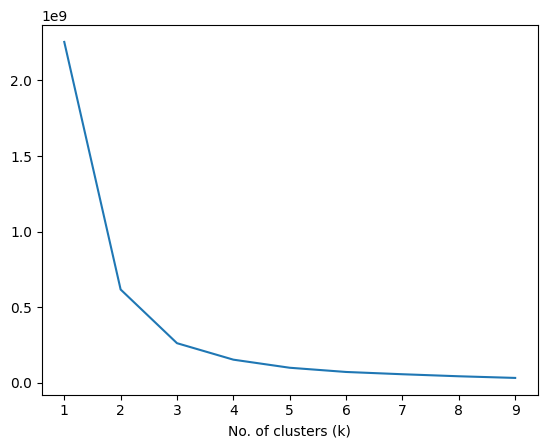

In [8]:
find_k(score_df,"recency")

- It looks like the optimal k can be either 3 or 4. We can often use business requirements as a guide to select the final k
- We will proceed with k = 4

In [9]:
# Assign the users into 4 clusters based on their recency scores
kmeans = KMeans(n_clusters=4).fit(score_df[["recency"]])
score_df["recency_cluster"] = kmeans.predict(score_df[["recency"]])

In [10]:
# Build a function to re-order the clusters as kmeans did not know the hiarchy of the cluters

def assign_cluster(df,cluster_col,score_col,ascending):
    new_df = df.groupby(by=cluster_col)[score_col].mean().reset_index()
    new_df = new_df.sort_values(by=score_col,ascending=ascending).reset_index(drop=True)
    new_df["new_cluster"] = new_df.index
    final_df = pd.merge(df,new_df[[cluster_col,"new_cluster"]],on=cluster_col)
    final_df = final_df.drop([cluster_col],axis=1)
    final_df = final_df.rename(columns={"new_cluster":cluster_col})

    return final_df

In [11]:
score_df = assign_cluster(score_df,"recency_cluster","recency",False)
score_df.groupby(by="recency_cluster")["recency"].describe()

,count,mean,std,min,25%,50%,75%,max
recency_cluster,,,,,,,,
0,4180.0,844.370096,97.457824,699.0,765.0,836.0,904.0,1095.0
1,5977.0,549.793877,77.866078,433.0,475.0,541.0,616.0,698.0
2,8905.0,312.706906,64.940152,204.0,258.0,310.0,367.0,432.0
3,12634.0,93.479579,56.165193,0.0,44.0,92.0,136.0,203.0


## Frequency

In [12]:
# Get the number of purchases of each customer
freq_df = merged_df.groupby(by="user_id").order_id.count().reset_index()
freq_df.columns = ["user_id","frequency"]

# Add recency to score_df
score_df = score_df.merge(freq_df,on="user_id")
score_df

,user_id,recency,recency_cluster,frequency
0,13,1058,0,1
1,20,1095,0,1
2,59,1064,0,1
3,104,1095,0,1
4,147,1094,0,1
...,...,...,...,...
31691,394231,0,3,1
31692,394255,0,3,1
31693,394257,0,3,1
31694,394268,0,3,2


/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/chaule/Fuzzy_Ecom/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


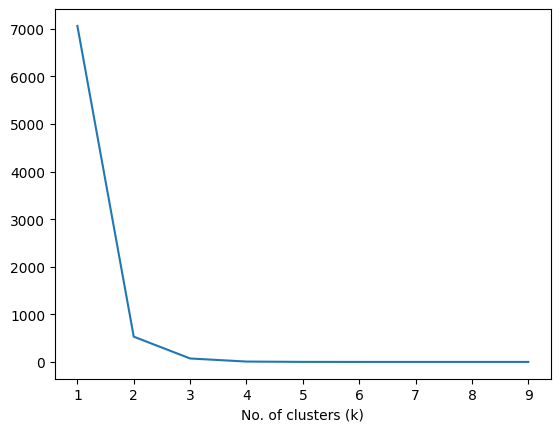

In [13]:
find_k(score_df,"frequency")

- We go with k = 3

In [14]:
# Assign the users into 3 clusters based on their frequency scores
kmeans = KMeans(n_clusters=3).fit(score_df[["frequency"]])
score_df["frequency_cluster"] = kmeans.predict(score_df[["frequency"]])
score_df = assign_cluster(score_df,"frequency_cluster","frequency",True) # ascending = True to make cluster 0 the worse
score_df.groupby(by="frequency_cluster")["frequency"].describe()

,count,mean,std,min,25%,50%,75%,max
frequency_cluster,,,,,,,,
0,23741.0,1.000000,0.000000,1.0,1.0,1.0,1.00,1.0
1,7661.0,2.000000,0.000000,2.0,2.0,2.0,2.00,2.0
2,294.0,3.272109,0.496511,3.0,3.0,3.0,3.75,6.0


In [15]:
score_df

,user_id,recency,recency_cluster,frequency,frequency_cluster
0,13,1058,0,1,0
1,20,1095,0,1,0
2,59,1064,0,1,0
3,104,1095,0,1,0
4,147,1094,0,1,0
...,...,...,...,...,...
31691,394231,0,3,1,0
31692,394255,0,3,1,0
31693,394257,0,3,1,0
31694,394268,0,3,2,1


## Monetary score

In [16]:
# Find the total monetary per customer
monetary_df = merged_df.groupby("user_id")[["price_usd"]].sum()
monetary_df.columns = ["monetary"]
# Add monetary to score_df
score_df = score_df.merge(monetary_df,on="user_id")
score_df["monetary"] = round(score_df["monetary"],2)
score_df

,user_id,recency,recency_cluster,frequency,frequency_cluster,monetary
0,13,1058,0,1,0,49.99
1,20,1095,0,1,0,49.99
2,59,1064,0,1,0,49.99
3,104,1095,0,1,0,49.99
4,147,1094,0,1,0,49.99
...,...,...,...,...,...,...
31691,394231,0,3,1,0,49.99
31692,394255,0,3,1,0,49.99
31693,394257,0,3,1,0,29.99
31694,394268,0,3,2,1,89.98


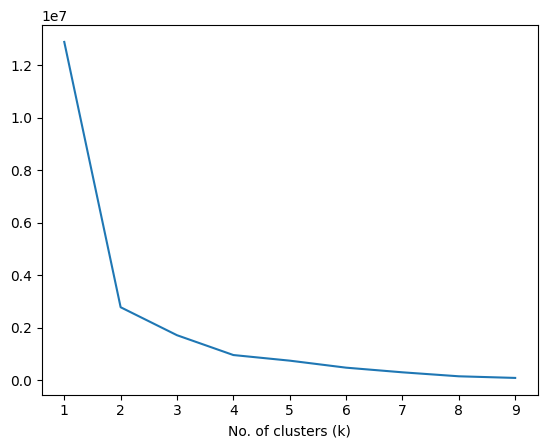

In [17]:
find_k(score_df,"monetary")

- We select k = 3

In [18]:
# Assign the users into 3 clusters based on their monetary score
kmeans = KMeans(n_clusters=3).fit(score_df[["monetary"]])
score_df["monetary_cluster"] = kmeans.predict(score_df[["monetary"]])
score_df = assign_cluster(score_df,"monetary_cluster","monetary",True) # ascending = True to make cluster 0 the worse
score_df.groupby(by="monetary_cluster")["monetary"].describe()

,count,mean,std,min,25%,50%,75%,max
monetary_cluster,,,,,,,,
0,19952.0,49.090441,3.302280,29.99,49.99,49.99,49.99,49.99
1,4415.0,62.253588,5.574766,59.98,59.99,59.99,59.99,75.98
2,7329.0,93.356212,16.590705,79.98,79.98,89.98,95.98,251.94


In [19]:
score_df[["recency","frequency","monetary"]].describe()

,recency,frequency,monetary
count,31696.000000,31696.000000,31696.000000
mean,340.145791,1.262778,61.159444
std,266.684753,0.472040,20.159307
min,0.000000,1.000000,29.990000
25%,111.000000,1.000000,49.990000
50%,282.000000,1.000000,49.990000
75%,506.000000,2.000000,75.980000
max,1095.000000,6.000000,251.940000


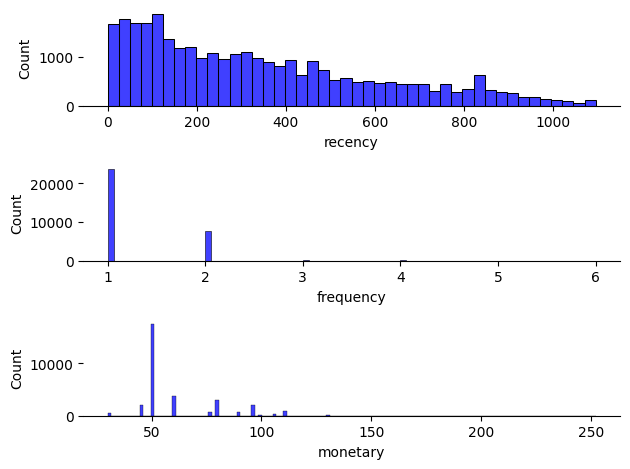

In [20]:
import seaborn as sns
f,ax = plt.subplots(3)

sns.despine(left=True)

sns.histplot(score_df.recency,color="b",ax=ax[0])
sns.histplot(score_df.frequency,color="b",ax=ax[1])
sns.histplot(score_df.monetary,color="b",ax=ax[2])

plt.tight_layout()


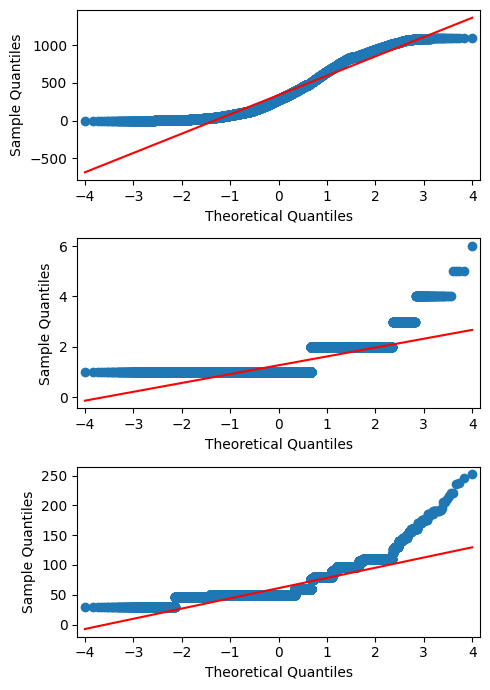

In [21]:
from statsmodels.graphics.gofplots import qqplot
f,ax = plt.subplots(3,1,figsize=(5,7))

qqplot(score_df["recency"],line="r",ax=ax[0],label="recency")
qqplot(score_df.frequency,line="r",ax=ax[1],label="frequency")
qqplot(score_df.monetary,line="r",ax=ax[2],label="monetary")


plt.tight_layout()


- The distributions of all 3 features are not normal
- Therefore we couldn't and shouldn't use statistical methods that assume normal distribution
- This justifies the need for advanced ML models

## Overall RFM score

In [22]:
score_df["rfm"] = score_df["recency_cluster"] + score_df["frequency_cluster"] + score_df["monetary_cluster"]
score_df.groupby("rfm")[["recency","frequency","monetary"]].mean()

,recency,frequency,monetary
rfm,,,
0,852.971661,1.000000,49.990000
1,565.118595,1.000000,50.539689
2,351.232175,1.000000,50.969071
3,130.559298,1.004811,49.813099
4,166.163060,1.252642,67.977408
5,280.050288,2.002562,88.874273
6,100.632985,2.031576,91.754277
7,89.709497,3.307263,150.290950


- This reveals interesting insights and characteristics of each group
- From this, we segment them into Low/Medium/High value segments based on their rfm score
  - Low: 0 - 2
  - Medium: 3 - 5
  - High: 6 - 7

In [23]:
# Put them into Low/Medium/High value segments based on the overall rfm score
score_df["segment"] = "low"
score_df.loc[score_df["rfm"]>2,"segment"] = "med"
score_df.loc[score_df["rfm"]>5,"segment"] = "high"
score_df

,user_id,recency,recency_cluster,frequency,frequency_cluster,monetary,monetary_cluster,rfm,segment
0,13,1058,0,1,0,49.99,0,0,low
1,20,1095,0,1,0,49.99,0,0,low
2,59,1064,0,1,0,49.99,0,0,low
3,104,1095,0,1,0,49.99,0,0,low
4,147,1094,0,1,0,49.99,0,0,low
...,...,...,...,...,...,...,...,...,...
31691,394231,0,3,1,0,49.99,0,3,med
31692,394255,0,3,1,0,49.99,0,3,med
31693,394257,0,3,1,0,29.99,0,3,med
31694,394268,0,3,2,1,89.98,2,6,high
